# 02 – Transformação e Limpeza dos Dados
## UCI SECOM Dataset – Tratamento de Sensores e Missing Values

**Objetivo desta etapa:**
- Carregar o dataset combinado (`secom_raw_combined.csv`)
- Analisar missing values por sensor
- Remover sensores com mais de 50% de missing
- Imputar valores faltantes remanescentes pela mediana
- Gerar a base final `secom_clean.csv` para análise e Tableau

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Garantir gráficos mais bonitos
sns.set(style="whitegrid")

# Caminhos (notebook dentro de /src)
BASE_DIR       = os.path.abspath(os.path.join(os.getcwd(), ".."))
PROCESSED_DIR  = os.path.join(BASE_DIR, "data", "processed")

RAW_COMBINED   = os.path.join(PROCESSED_DIR, "secom_raw_combined.csv")
CLEAN_FILE     = os.path.join(PROCESSED_DIR, "secom_clean_from_notebook.csv")

print("BASE_DIR     :", BASE_DIR)
print("RAW_COMBINED :", RAW_COMBINED)
print("CLEAN_FILE   :", CLEAN_FILE)
print("Arquivo raw existe? ", os.path.exists(RAW_COMBINED))

BASE_DIR     : /Users/dtp/Desktop/projetos_BI/projeto-02-quality-analytics-secom
RAW_COMBINED : /Users/dtp/Desktop/projetos_BI/projeto-02-quality-analytics-secom/data/processed/secom_raw_combined.csv
CLEAN_FILE   : /Users/dtp/Desktop/projetos_BI/projeto-02-quality-analytics-secom/data/processed/secom_clean_from_notebook.csv
Arquivo raw existe?  True


## 1. Carregar o dataset combinado (após 01_extract)

Nesta etapa usamos o arquivo `secom_raw_combined.csv`, que já contém:
- `Unit_ID`
- `Label` (1 = PASS, -1 = FAIL)
- `Timestamp`
- `Result` (PASS / FAIL)
- 590 colunas de sensores (`Sensor_001` a `Sensor_590`)

In [5]:
df_raw = pd.read_csv(RAW_COMBINED)

print(f"Shape do dataset combinado: {df_raw.shape[0]} linhas × {df_raw.shape[1]} colunas")

# Ver primeiras linhas
df_raw.head()

Shape do dataset combinado: 1567 linhas × 594 colunas


,Unit_ID,Label,Timestamp,Result,Sensor_001,Sensor_002,Sensor_003,Sensor_004,Sensor_005,Sensor_006,...,Sensor_581,Sensor_582,Sensor_583,Sensor_584,Sensor_585,Sensor_586,Sensor_587,Sensor_588,Sensor_589,Sensor_590
0,1,-1,2008-07-19 11:55:00,FAIL,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,...,NaN,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN
1,2,-1,2008-07-19 12:32:00,FAIL,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,...,0.0060,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045
2,3,1,2008-07-19 13:17:00,PASS,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,...,0.0148,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602
3,4,-1,2008-07-19 14:43:00,FAIL,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,...,0.0044,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432
4,5,-1,2008-07-19 15:22:00,FAIL,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,...,NaN,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432


In [7]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1567 entries, 0 to 1566
Columns: 594 entries, Unit_ID to Sensor_590
dtypes: float64(590), int64(2), object(2)
memory usage: 7.1+ MB


## 2. Análise detalhada de Missing Values por sensor

Vamos:
- Focar apenas nas colunas de sensores (`Sensor_*`)
- Calcular o percentual de missing por coluna
- Identificar quantos sensores têm mais de 50% de NaN
- Visualizar a distribuição geral de missing

In [10]:
# Seleciona apenas colunas de sensores
sensor_cols = [c for c in df_raw.columns if c.startswith("Sensor_")]
len(sensor_cols), sensor_cols[:5]

(590, ['Sensor_001', 'Sensor_002', 'Sensor_003', 'Sensor_004', 'Sensor_005'])

In [12]:
# Percentual de missing por sensor
missing_pct = df_raw[sensor_cols].isnull().mean().sort_values(ascending=False)

print(f"Total de sensores          : {len(sensor_cols)}")
print(f"Sensores com algum missing : {(missing_pct > 0).sum()}")
print(f"Sensores com >50% missing  : {(missing_pct > 0.50).sum()}")
print(f"Sensores com >80% missing  : {(missing_pct > 0.80).sum()}")
print(f"Sensores sem missing       : {(missing_pct == 0).sum()}")

print("\nTOP 20 sensores com mais missing:")
missing_pct.head(20)

Total de sensores          : 590
Sensores com algum missing : 538
Sensores com >50% missing  : 28
Sensores com >80% missing  : 8
Sensores sem missing       : 52

TOP 20 sensores com mais missing:


Sensor_158    0.911934
Sensor_293    0.911934
Sensor_294    0.911934
Sensor_159    0.911934
Sensor_493    0.855775
Sensor_359    0.855775
Sensor_086    0.855775
Sensor_221    0.855775
Sensor_247    0.649649
Sensor_110    0.649649
Sensor_111    0.649649
Sensor_112    0.649649
Sensor_519    0.649649
Sensor_517    0.649649
Sensor_246    0.649649
Sensor_245    0.649649
Sensor_383    0.649649
Sensor_384    0.649649
Sensor_385    0.649649
Sensor_518    0.649649
dtype: float64

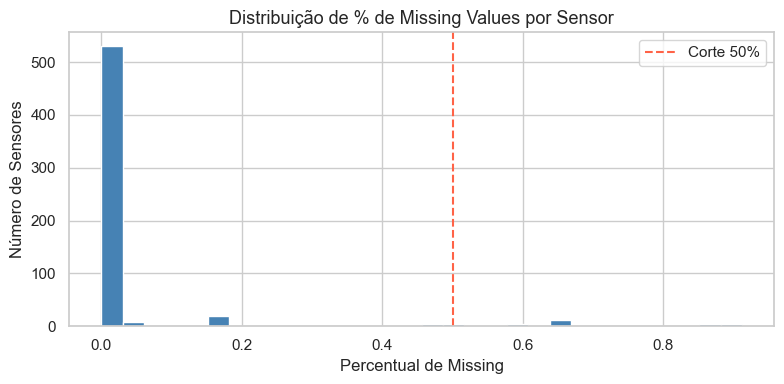

In [14]:
fig, ax = plt.subplots(figsize=(8, 4))
missing_pct.plot(kind="hist", bins=30, color="steelblue", edgecolor="white", ax=ax)
ax.axvline(0.50, color="tomato", linestyle="--", label="Corte 50%")
ax.set_title("Distribuição de % de Missing Values por Sensor", fontsize=13)
ax.set_xlabel("Percentual de Missing")
ax.set_ylabel("Número de Sensores")
ax.legend()
plt.tight_layout()
plt.show()

Use essa célula para anotar no markdown como está a “qualidade” geral dos sensores.

### Decisão de regra de limpeza

Com base na análise:

- 590 sensores no total
- 28 sensores com mais de 50% de valores faltantes
- 8 sensores com mais de 80% de valores faltantes
- 52 sensores sem nenhum missing

**Regra adotada:**
- Remover sensores com **mais de 50% de missing values**
- Nos sensores restantes, imputar os NaNs pela **mediana** de cada coluna

Essa escolha equilibra:
- Remover variáveis pouco confiáveis (muitos NaNs)
- Preservar o máximo de informação possível para análise/modelagem

In [18]:
threshold = 0.50

# Lista de sensores a manter e a remover
keep_sensors = missing_pct[missing_pct <= threshold].index.tolist()
drop_sensors = missing_pct[missing_pct > threshold].index.tolist()

print(f"Sensores a remover (> {threshold*100:.0f}% missing): {len(drop_sensors)}")
print(drop_sensors[:10])  # mostra alguns

non_sensor_cols = [c for c in df_raw.columns if not c.startswith("Sensor_")]
final_cols = non_sensor_cols + keep_sensors

df_filtered = df_raw[final_cols].copy()

print(f"Shape após remoção de sensores ruins: {df_filtered.shape}")

Sensores a remover (> 50% missing): 28
['Sensor_158', 'Sensor_293', 'Sensor_294', 'Sensor_159', 'Sensor_493', 'Sensor_359', 'Sensor_086', 'Sensor_221', 'Sensor_247', 'Sensor_110']
Shape após remoção de sensores ruins: (1567, 566)


In [20]:
sensor_cols_filtered = [c for c in df_filtered.columns if c.startswith("Sensor_")]

missing_before_total = df_filtered[sensor_cols_filtered].isnull().sum().sum()
print(f"Total de missing (sensores) ANTES da imputação: {missing_before_total}")

# Percentual médio de missing nos sensores restantes
print("Média de % de missing nos sensores restantes:",
      df_filtered[sensor_cols_filtered].isnull().mean().mean())

Total de missing (sensores) ANTES da imputação: 11683
Média de % de missing nos sensores restantes: 0.013266277107694966


In [22]:
# Calcula a mediana de cada sensor
medians = df_filtered[sensor_cols_filtered].median()

# Imputa NaNs com a mediana
df_clean = df_filtered.copy()
df_clean[sensor_cols_filtered] = df_clean[sensor_cols_filtered].fillna(medians)

missing_after_total = df_clean[sensor_cols_filtered].isnull().sum().sum()
print(f"Total de missing (sensores) DEPOIS da imputação: {missing_after_total}")

Total de missing (sensores) DEPOIS da imputação: 0


## 3. Resumo da transformação

- **Shape antes:** 1.567 linhas × 594 colunas  
  (590 sensores + 4 colunas de controle)

- **Shape depois:** 1.567 linhas × 566 colunas  
  (562 sensores + 4 colunas de controle)

- **Sensores removidos:** 28 (mais de 50% de missing)  
- **Sensores mantidos:** 562  
- **Total de missing imputados:** 11.683 valores (passaram a ser a mediana por sensor)  
- **Base final:** sem valores faltantes nos sensores

In [25]:
df_clean.to_csv(CLEAN_FILE, index=False)
print("Base limpa salva em:", CLEAN_FILE)

Base limpa salva em: /Users/dtp/Desktop/projetos_BI/projeto-02-quality-analytics-secom/data/processed/secom_clean_from_notebook.csv


In [27]:
print(df_clean.shape)
print("Existe algum NaN no dataset final?", df_clean.isnull().any().any())

(1567, 566)
Existe algum NaN no dataset final? False
